In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureRavdess.csv')

In [3]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
0,-673.301697,69.508095,-3.494582,18.998575,5.041687,4.626438,-7.605268,-0.057042,-16.231766,-0.299419,...,31.995356,-0.051473,0.025316,-0.044013,-0.079353,0.022513,0.010037,1,1,1
1,-663.297852,67.747589,-6.961255,22.244839,5.313937,2.970508,-6.046401,-3.327282,-17.383774,0.806942,...,31.223174,-0.079423,0.034342,-0.070702,-0.074578,0.025509,-0.001626,1,1,1
2,-664.776184,70.703842,-4.903909,18.797665,1.573513,4.084437,-6.752044,-3.895945,-15.839313,-2.361090,...,31.753796,-0.024101,-0.010724,-0.007700,0.022802,-0.000364,0.032532,1,1,1
3,-660.674133,69.261803,-1.020717,19.743364,3.635317,6.417199,-5.448439,-4.090719,-15.130262,-1.551855,...,30.522612,-0.065819,0.008619,0.004848,-0.030447,-0.000754,0.014753,1,1,1
4,-699.495178,76.727394,-1.602398,21.554548,4.587931,6.054961,-8.122147,-1.003357,-15.158166,-2.688365,...,31.293542,-0.070505,0.011104,0.031151,-0.115693,0.024391,0.003346,1,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [5]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1764848725.472898 4147135 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step


In [7]:
print(gender_predictions)

[[7.7384239e-04]
 [7.8950549e-04]
 [1.0120951e-03]
 ...
 [9.9847502e-01]
 [9.9787855e-01]
 [9.9846315e-01]]


In [8]:
male_rows = gender_predictions.flatten() >= 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} female samples.")

Filtered dataset contains 721 female samples.


In [9]:
df.shape

(721, 196)

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,0.1,0.2,speaker
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489,0,1,2
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258,0,1,2
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748,0,1,2
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018,0,1,2
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015,0,8,24
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375,0,8,24
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219,0,8,24
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220,0,8,24


In [11]:
data.iloc[:,-3] == 0

0       False
1       False
2       False
3       False
4       False
        ...  
1435     True
1436     True
1437     True
1438     True
1439     True
Name: 0.1, Length: 1440, dtype: bool

In [12]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [13]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
60,-626.065857,67.129211,-14.506104,13.734784,-8.915299,-0.597560,-9.627712,-6.697053,-7.643127,1.682984,...,15.032267,17.122944,17.137267,32.684056,-0.035477,0.046495,0.018824,-0.060412,0.011128,0.000489
61,-622.978882,61.610241,-16.155281,17.274385,-10.515155,-0.012929,-9.384588,-5.405496,-6.061921,0.427206,...,15.800671,16.939402,16.786359,32.054128,-0.038423,0.033620,0.028817,-0.024666,0.011614,-0.008258
62,-594.977844,62.693829,-16.257780,9.051161,-9.175509,-0.249130,-9.898236,-7.671722,-8.782819,0.426915,...,15.484927,17.181703,18.043089,31.869979,-0.053699,0.053169,0.032318,-0.044163,0.002315,-0.013748
63,-612.936279,58.990162,-15.687172,10.080914,-11.711167,-1.830589,-11.331991,-8.769240,-10.589375,-0.807020,...,15.257555,16.719364,17.726324,31.140206,-0.045528,0.042565,-0.070671,-0.055261,0.010003,-0.008018
64,-639.557617,64.624420,-8.859457,17.944416,-9.782133,2.161584,-7.936422,-4.958043,-6.853294,0.523445,...,16.251168,17.629721,16.558219,31.837218,-0.089607,0.068644,-0.019986,-0.011248,0.001546,0.004188
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,-558.443298,34.201637,-25.876736,3.420890,-22.962826,-6.289969,-22.845768,-13.475706,-11.609130,-4.602691,...,16.391113,18.151034,17.573820,31.661293,-0.020466,0.014107,0.020899,0.050697,-0.005623,0.022015
1436,-509.914642,49.378990,-22.979485,-0.832579,-23.050257,-10.238819,-17.452888,-8.696088,-14.158811,0.367432,...,16.270073,17.091367,17.932740,31.846921,-0.040751,0.017479,0.014917,0.015533,0.016873,-0.000375
1437,-517.733276,40.459633,-27.217442,2.902560,-22.611633,-14.189220,-19.589163,-8.899709,-12.807209,3.745601,...,16.128660,16.947312,18.503842,31.628901,-0.032364,0.032572,-0.050994,0.009171,0.007204,0.013219
1438,-463.998352,35.496925,-14.260783,9.399699,-19.878208,0.799514,-18.052525,-4.351163,-7.299998,0.214021,...,16.307834,17.859030,17.360766,31.137002,-0.045889,0.027680,-0.042989,-0.060098,0.005997,-0.009220


In [14]:
y

60      1
61      1
62      1
63      1
64      2
       ..
1435    8
1436    8
1437    8
1438    8
1439    8
Name: 0.2, Length: 721, dtype: int64

In [15]:
X_speaker

60       2
61       2
62       2
63       2
64       2
        ..
1435    24
1436    24
1437    24
1438    24
1439    24
Name: speaker, Length: 721, dtype: int64

In [16]:
X.shape, y.shape

((721, 193), (721,))

In [17]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [18]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
559,-335.606201,35.947792,-41.001568,3.906434,-7.070841,-16.843096,-15.933081,-16.861418,-23.478594,4.073371,...,17.098972,17.900762,21.640777,33.018618,-0.034330,-0.008804,-0.039289,-0.026896,0.001394,-0.019109
1317,-497.885834,51.342960,-25.292511,2.316003,-10.581579,-6.288764,-19.012859,-8.212265,-19.555786,4.992507,...,17.122013,17.902528,18.658415,32.487180,-0.013387,0.005819,-0.052275,0.041031,0.012859,-0.000141
197,-474.748474,29.661650,-30.214418,7.445138,-14.909060,-7.850755,-7.015169,-11.177808,-9.779725,-0.272173,...,17.673749,18.615454,19.359512,29.750967,-0.021067,0.042943,-0.001346,0.040493,-0.002825,-0.004227
185,-631.926697,68.734642,-25.842701,10.414717,-13.844299,-2.994180,-16.271351,-11.329893,-13.687139,-0.683531,...,17.221955,18.240717,17.044966,32.192209,-0.083303,-0.019094,0.067265,0.080696,-0.027137,0.001621
201,-562.606140,41.196228,-15.717087,5.585703,-13.201707,-5.571932,-10.110978,-13.677787,-14.205627,-1.181797,...,16.753707,17.432653,17.279526,31.426357,-0.013960,0.057596,0.050123,-0.033093,0.004843,-0.002377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,-644.772583,61.138340,-13.468080,8.149558,-16.597828,-1.040846,-21.411978,-11.137970,-14.684502,-1.909690,...,15.628375,16.960961,16.436982,32.163103,-0.057815,0.065458,0.012634,0.002165,0.018058,-0.027380
226,-566.816162,43.368359,-15.307161,2.067335,-9.152300,-6.163722,-13.324579,-12.101171,-12.638726,-1.018285,...,17.029112,17.465603,17.662481,29.864309,-0.039929,0.013363,-0.034609,-0.003479,0.025737,-0.010313
570,-478.766022,73.137833,-16.414293,7.870032,-7.602270,-1.200238,-17.209576,-15.361103,-11.571535,1.926383,...,17.162428,19.912594,20.361990,31.162177,0.007285,0.001611,-0.019291,-0.024284,-0.000465,0.001735
915,-559.119263,47.521179,-13.219441,10.803747,-4.820639,-7.630402,-17.089399,-8.979336,-12.113929,3.582775,...,15.592766,16.871436,17.653203,31.580140,-0.006078,0.050865,0.016923,-0.080251,0.019615,0.001849


In [19]:
X_speaker

559     10
1317    22
197      4
185      4
201      4
        ..
191      4
226      4
570     10
915     16
222      4
Name: speaker, Length: 721, dtype: int64

In [20]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [21]:
y1

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]], shape=(721, 8))

In [22]:
X.shape, y1.shape

((721, 193), (721, 8))

In [23]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [24]:
X2.shape, X2_speaker.shape, y2.shape

((721, 193), (721,), (721,))

In [25]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    #model.add(Conv1D(128, 5,padding='same',))
    #model.add(Activation('relu'))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(8))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    #model.summary()
    return model

In [26]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [27]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-335.606201,35.947792,-41.001568,3.906434,-7.070841,-16.843096,-15.933081,-16.861418,-23.478594,4.073371,...,17.098972,17.900762,21.640777,33.018618,-0.034330,-0.008804,-0.039289,-0.026896,0.001394,-0.019109
1,-497.885834,51.342960,-25.292511,2.316003,-10.581579,-6.288764,-19.012859,-8.212265,-19.555786,4.992507,...,17.122013,17.902528,18.658415,32.487180,-0.013387,0.005819,-0.052275,0.041031,0.012859,-0.000141
2,-474.748474,29.661650,-30.214418,7.445138,-14.909060,-7.850755,-7.015169,-11.177808,-9.779725,-0.272173,...,17.673749,18.615454,19.359512,29.750967,-0.021067,0.042943,-0.001346,0.040493,-0.002825,-0.004227
3,-631.926697,68.734642,-25.842701,10.414717,-13.844299,-2.994180,-16.271351,-11.329893,-13.687139,-0.683531,...,17.221955,18.240717,17.044966,32.192209,-0.083303,-0.019094,0.067265,0.080696,-0.027137,0.001621
4,-562.606140,41.196228,-15.717087,5.585703,-13.201707,-5.571932,-10.110978,-13.677787,-14.205627,-1.181797,...,16.753707,17.432653,17.279526,31.426357,-0.013960,0.057596,0.050123,-0.033093,0.004843,-0.002377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,-644.772583,61.138340,-13.468080,8.149558,-16.597828,-1.040846,-21.411978,-11.137970,-14.684502,-1.909690,...,15.628375,16.960961,16.436982,32.163103,-0.057815,0.065458,0.012634,0.002165,0.018058,-0.027380
717,-566.816162,43.368359,-15.307161,2.067335,-9.152300,-6.163722,-13.324579,-12.101171,-12.638726,-1.018285,...,17.029112,17.465603,17.662481,29.864309,-0.039929,0.013363,-0.034609,-0.003479,0.025737,-0.010313
718,-478.766022,73.137833,-16.414293,7.870032,-7.602270,-1.200238,-17.209576,-15.361103,-11.571535,1.926383,...,17.162428,19.912594,20.361990,31.162177,0.007285,0.001611,-0.019291,-0.024284,-0.000465,0.001735
719,-559.119263,47.521179,-13.219441,10.803747,-4.820639,-7.630402,-17.089399,-8.979336,-12.113929,3.582775,...,15.592766,16.871436,17.653203,31.580140,-0.006078,0.050865,0.016923,-0.080251,0.019615,0.001849


In [28]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,10
1,22
2,4
3,4
4,4
...,...
716,4
717,4
718,10
719,16


In [29]:
speakers = X_speaker.unique()
speakers

array([10, 22,  4,  8, 12, 18, 14, 16,  2, 24,  6, 20, 19])

In [30]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,10
1,22
2,4
3,4
4,4
...,...
716,4
717,4
718,10
719,16


In [31]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-335.606201,35.947792,-41.001568,3.906434,-7.070841,-16.843096,-15.933081,-16.861418,-23.478594,4.073371,...,17.900762,21.640777,33.018618,-0.034330,-0.008804,-0.039289,-0.026896,0.001394,-0.019109,10
1,-497.885834,51.342960,-25.292511,2.316003,-10.581579,-6.288764,-19.012859,-8.212265,-19.555786,4.992507,...,17.902528,18.658415,32.487180,-0.013387,0.005819,-0.052275,0.041031,0.012859,-0.000141,22
2,-474.748474,29.661650,-30.214418,7.445138,-14.909060,-7.850755,-7.015169,-11.177808,-9.779725,-0.272173,...,18.615454,19.359512,29.750967,-0.021067,0.042943,-0.001346,0.040493,-0.002825,-0.004227,4
3,-631.926697,68.734642,-25.842701,10.414717,-13.844299,-2.994180,-16.271351,-11.329893,-13.687139,-0.683531,...,18.240717,17.044966,32.192209,-0.083303,-0.019094,0.067265,0.080696,-0.027137,0.001621,4
4,-562.606140,41.196228,-15.717087,5.585703,-13.201707,-5.571932,-10.110978,-13.677787,-14.205627,-1.181797,...,17.432653,17.279526,31.426357,-0.013960,0.057596,0.050123,-0.033093,0.004843,-0.002377,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,-644.772583,61.138340,-13.468080,8.149558,-16.597828,-1.040846,-21.411978,-11.137970,-14.684502,-1.909690,...,16.960961,16.436982,32.163103,-0.057815,0.065458,0.012634,0.002165,0.018058,-0.027380,4
717,-566.816162,43.368359,-15.307161,2.067335,-9.152300,-6.163722,-13.324579,-12.101171,-12.638726,-1.018285,...,17.465603,17.662481,29.864309,-0.039929,0.013363,-0.034609,-0.003479,0.025737,-0.010313,4
718,-478.766022,73.137833,-16.414293,7.870032,-7.602270,-1.200238,-17.209576,-15.361103,-11.571535,1.926383,...,19.912594,20.361990,31.162177,0.007285,0.001611,-0.019291,-0.024284,-0.000465,0.001735,10
719,-559.119263,47.521179,-13.219441,10.803747,-4.820639,-7.630402,-17.089399,-8.979336,-12.113929,3.582775,...,16.871436,17.653203,31.580140,-0.006078,0.050865,0.016923,-0.080251,0.019615,0.001849,16


In [32]:
# Get random 5 speakers

speaker_counts = X_combined['speaker'].value_counts()
total_speakers = speaker_counts.head(12).index.to_numpy()
selected_speakers = np.random.choice(total_speakers, size=5, replace=False)

print("Selected speakers:", selected_speakers)

Selected speakers: [ 6 24 10  2 18]


In [33]:
def fisher_score_manual(X, y):
    n_samples, n_features = X.shape
    classes = np.unique(y)
    score = np.zeros(n_features)
    for i in range(n_features):
        numerator = 0
        denominator = 0
        overall_mean = np.mean(X[:, i])
        for c in classes:
            Xc = X[y==c, i]
            nc = len(Xc)
            mean_c = np.mean(Xc)
            var_c = np.var(Xc)
            numerator += nc * (mean_c - overall_mean)**2
            denominator += nc * var_c
        score[i] = numerator / denominator if denominator != 0 else 0
    return score

In [34]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=720
num_fea=125
a=create_index(kfold,totalsize)

top_features_per_fold = []
importance_per_fold = []

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='ravdess_speaker_female'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score_manual(X_train_scaled, y_train_fs)

    # Sort features by score (high → low)
    sorted_indices = np.argsort(score)[::-1]

    # Select top features
    fs_indices = sorted_indices[:num_fea]

    # Get scores of selected features
    selected_scores = score[fs_indices]

    # Compute relative importance (percentage)
    relative_importance = selected_scores / selected_scores.sum() * 100

    top_features_per_fold.append(fs_indices)
    importance_per_fold.append(relative_importance)

    print(f"Top {num_fea} features: {fs_indices} ...")
    print("Importances %:", relative_importance)
    print("Scores:", selected_scores)


===== Fold 0 =====
Test speaker: 6
Train speakers: [ 2  4  8 10 12 14 16 18 19 20 22 24]
No overlap in fold 0.
Top 125 features: [  0   2   1  20 185   5 183   4   3 155 184 154 157 182  21  22 153  19
 142  17  35 140  77 141  18 156  45  23 151 150 186 106 139 138  44 158
 136 131 132  34 152   7 137 129  12 107 104 143  55 166 144 105 133 102
 123  76  33 130  41  78 179 174 173  75  74 171  43  56 128 176 165 177
 181 127  42 115  93 175 103 149  87 122  32 134 145 108 178 109 159  10
  24 148  57  36  91  99 170 116  40 164 110 114 180 172  90 146   6 147
 113  79  94  13  37  80  95  51 163 161  92  31  16 135  58 124  62] ...
Importances %: [4.48366389 2.66389802 1.83635035 1.6839237  1.62447172 1.52683508
 1.29794136 1.26120776 1.23022322 1.21526064 1.20856845 1.19364745
 1.18614248 1.17906601 1.12857018 1.07504609 1.07041246 1.06393669
 1.02349897 1.02338188 1.02097379 0.98149235 0.97757233 0.96426803
 0.94442477 0.9259475  0.91123778 0.90905552 0.90174981 0.88096387
 0.86155

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

num_folds = 5

# Collect all unique features
all_features = sorted(set(np.concatenate(top_features_per_fold)))

df = pd.DataFrame(0.0, index=all_features, columns=range(kfold), dtype=float)

for fold_idx in range(kfold):
    indices = top_features_per_fold[fold_idx]
    importance = importance_per_fold[fold_idx]
    df.loc[indices, fold_idx] = importance

# Average importance across folds
df['avg_importance'] = df.mean(axis=1)

# Sort by average importance
df_sorted = df['avg_importance'].sort_values(ascending=True)


In [36]:
df_sorted.values[-10:]

array([1.24978824, 1.25284744, 1.27314751, 1.29276784, 1.49159085,
       1.68097207, 1.70228317, 1.88920821, 2.4974179 , 4.41232605])

In [37]:
df_sorted.index[-10:].astype(str)

Index(['182', '183', '3', '4', '5', '20', '185', '1', '2', '0'], dtype='object')

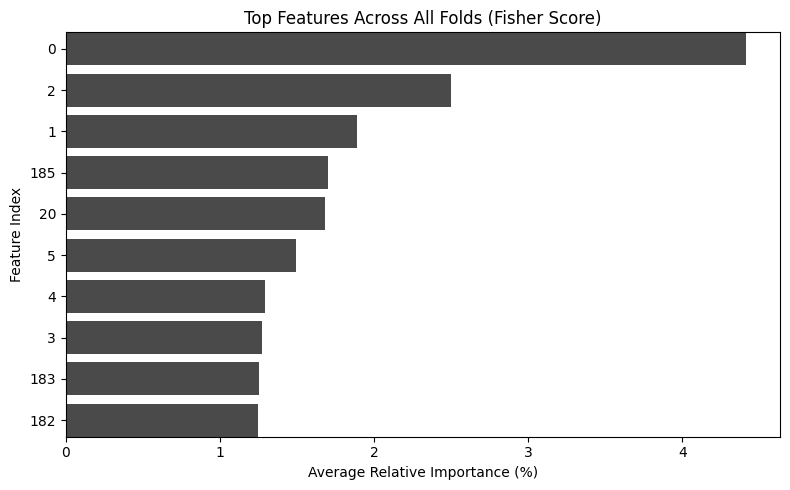

In [38]:
plt.figure(figsize=(8, 5))  # taller figure for many features
bars = plt.barh(df_sorted.index[-10:].astype(str), df_sorted.values[-10:], color='#4A4A4A')  # graphite color

plt.xlabel("Average Relative Importance (%)")
plt.ylabel("Feature Index")
plt.title("Top Features Across All Folds (Fisher Score)")

plt.margins(y=0)
plt.tight_layout()
plt.savefig("appendix_top10.png", bbox_inches='tight')
plt.show()

In [40]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=720
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='ravdess_speaker_female'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=200, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 2
Train speakers: [ 4  6  8 10 12 14 16 18 19 20 22 24]
No overlap in fold 0.
Top 125 features: [  0   2   1   7  10   5 117  75 165 126] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.1876 - loss: 2.0793 - val_accuracy: 0.1667 - val_loss: 2.0699
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2769 - loss: 1.8849 - val_accuracy: 0.1500 - val_loss: 2.0829
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3555 - loss: 1.7439 - val_accuracy: 0.1500 - val_loss: 2.0974
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3631 - loss: 1.6541 - val_accuracy: 0.1333 - val_loss: 2.1078
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4251 - loss: 1.5883 - val_accuracy: 0.1333 - val_loss: 2.1216
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4826 - loss: 1.5080 - val_accuracy: 0.1167 - val_loss: 2.1340
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4977 - loss: 1.4662 - val_accuracy: 0.1167 - val_loss: 2.1452
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5144 - loss: 1.4265 - val_accuracy: 0.1333 - val_l

Fold 0 Test Accuracy: 0.6333

===== Fold 1 =====
Test speaker: 24
Train speakers: [ 2  4  6  8 10 12 14 16 18 19 20 22]
No overlap in fold 1.
Top 125 features: [  0   2   1   8   6   5 111  48 164 142] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


...

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.2133 - loss: 2.0691 - val_accuracy: 0.1333 - val_loss: 2.0730
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2753 - loss: 1.8478 - val_accuracy: 0.1333 - val_loss: 2.0860
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3419 - loss: 1.7587 - val_accuracy: 0.1333 - val_loss: 2.0994
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4191 - loss: 1.6386 - val_accuracy: 0.1333 - val_loss: 2.1151
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4569 - loss: 1.5488 - val_accuracy: 0.1333 - val_loss: 2.1338
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4766 - loss: 1.4996 - val_accuracy: 0.1333 - val_loss: 2.1566
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4917 - loss: 1.4517 - val_accuracy: 0.1333 - val_loss: 2.1715
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5340 - loss: 1.4103 - val_accuracy: 0.1333 - val_l


===== Fold 4 =====
Test speaker: 20
Train speakers: [ 2  4  6  8 10 12 14 16 18 19 22 24]
No overlap in fold 4.
Top 125 features: [  0   2   1  11   6   5 103  72 167 145] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.1785 - loss: 2.3507 - val_accuracy: 0.1000 - val_loss: 2.0721
Epoch 2/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2980 - loss: 1.8785 - val_accuracy: 0.1333 - val_loss: 2.0846
Epoch 3/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3661 - loss: 1.7372 - val_accuracy: 0.2167 - val_loss: 2.1002
Epoch 4/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4372 - loss: 1.6609 - val_accuracy: 0.1833 - val_loss: 2.1164
Epoch 5/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4191 - loss: 1.5761 - val_accuracy: 0.1667 - val_loss: 2.1276
Epoch 6/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4826 - loss: 1.4875 - val_accuracy: 0.1500 - val_loss: 2.1410
Epoch 7/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5038 - loss: 1.4426 - val_accuracy: 0.1333 - val_loss: 2.1445
Epoch 8/700
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5507 - loss: 1.3784 - val_accuracy: 0.1833 - val_l

Fold 4 Test Accuracy: 0.5000

===== Cross-validation results =====
Fold 0: Loss=1.4826, Accuracy=0.6333
Fold 1: Loss=1.6318, Accuracy=0.5000
Fold 2: Loss=1.6787, Accuracy=0.4000
Fold 3: Loss=1.7438, Accuracy=0.4167
Fold 4: Loss=1.6372, Accuracy=0.5000

Average accuracy: 0.4900


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'ravdess_speaker_female'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

2026-03-02 12:37:58.966747: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-02 12:37:58.967012: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 12:37:58.996173: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-02 12:37:59.645886: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or


Fold 0: Accuracy = 63.33%
              precision    recall  f1-score   support

       angry     0.4286    0.7500    0.5455         4
        calm     0.7000    0.8750    0.7778         8
     disgust     0.7500    0.7500    0.7500         8
     fearful     0.2857    0.2500    0.2667         8
       happy     0.8571    0.7500    0.8000         8
     neutral     0.0000    0.0000    0.0000         8
         sad     0.6364    0.8750    0.7368         8
   surprised     0.7778    0.8750    0.8235         8

    accuracy                         0.6333        60
   macro avg     0.5544    0.6406    0.5875        60
weighted avg     0.5628    0.6333    0.5903        60


Fold 1: Accuracy = 50.00%
              precision    recall  f1-score   support

       angry     0.0000    0.0000    0.0000         4
        calm     0.4286    0.3750    0.4000         8
     disgust     0.2727    0.3750    0.3158         8
     fearful     0.2222    0.2500    0.2353         8
       happy     0.7000 

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _


Fold 3: Accuracy = 41.67%
              precision    recall  f1-score   support

       angry     0.2000    0.2500    0.2222         4
        calm     0.4000    0.5000    0.4444         8
     disgust     0.2381    0.6250    0.3448         8
     fearful     0.0000    0.0000    0.0000         8
       happy     0.6000    0.7500    0.6667         8
     neutral     0.5000    0.6250    0.5556         8
         sad     1.0000    0.2500    0.4000         8
   surprised     1.0000    0.2500    0.4000         8

    accuracy                         0.4167        60
   macro avg     0.4923    0.4062    0.3792        60
weighted avg     0.5117    0.4167    0.3897        60


Fold 4: Accuracy = 50.00%
              precision    recall  f1-score   support

       angry     1.0000    0.2500    0.4000         4
        calm     0.4211    1.0000    0.5926         8
     disgust     0.5000    0.3750    0.4286         8
     fearful     0.8333    0.6250    0.7143         8
       happy     0.4286 

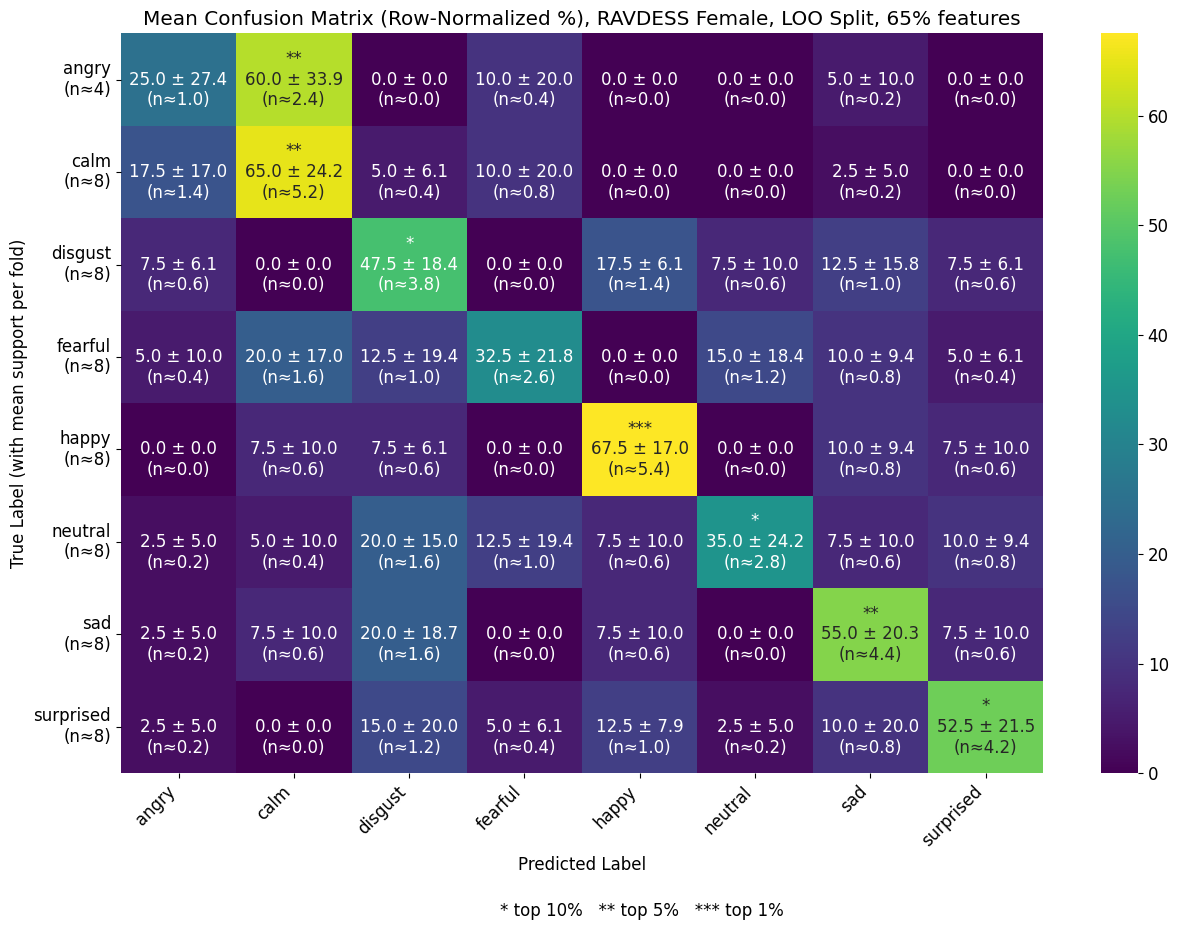

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_ravdess_speaker_female.npy', conf_matrices_percent)

mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Mean raw counts per fold
mean_counts = np.mean(conf_matrices, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols + raw counts
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}\n(n≈{mean_counts[i, j]:.1f})"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

# Per-class support (mean samples per true class per fold)
mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

# Plot
plt.figure(figsize=(13, 9))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)
ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(row_labels, rotation=0)
plt.title("Mean Confusion Matrix (Row-Normalized %), RAVDESS Female, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label (with mean support per fold)")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%\n",
            ha="center", fontsize=12)
plt.savefig("cm_ravdess_speaker_female.eps", bbox_inches='tight')
plt.show()

In [3]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix, classification_report

savedir = 'ravdess_speaker_male'
num_folds = 5
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices_male = []

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fold_reports = []
fold_macro_f1 = []

for i in range(num_folds):
    model_name = f"Model_{i}"
    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")
    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices_male.append(cm)

    report_dict = classification_report(y_true_labels, y_pred_labels,
                                        target_names=listik, digits=4, output_dict=True)
    fold_reports.append(report_dict)
    fold_macro_f1.append(report_dict['macro avg']['f1-score'])

    print(f"\n{'='*60}")
    print(f"Fold {i}: Accuracy = {acc:.2f}%")
    print(f"{'='*60}")
    print(classification_report(y_true_labels, y_pred_labels,
                                target_names=listik, digits=4))

# array: (num_folds, num_classes, num_classes)
conf_matrices_male = np.array(conf_matrices_male)

mean_acc = np.mean(accuracies)
print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))
n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")


# Macro-F1 summary
macro_f1_arr = np.array(fold_macro_f1)
mean_macro_f1 = np.mean(macro_f1_arr)
std_macro_f1 = np.std(macro_f1_arr)
ci95_f1 = 1.96 * (std_macro_f1 / np.sqrt(num_folds))
print(f"\nMacro-F1: {mean_macro_f1:.4f} ± {std_macro_f1:.4f}  "
      f"\n95% CI: [{mean_macro_f1 - ci95_f1:.4f}, {mean_macro_f1 + ci95_f1:.4f}]")

# Per-class precision / recall / F1 (mean ± SD across folds)
print(f"\n{' Per-Class Metrics (mean ± SD across folds)':=^93}\n")
print(f"{'Class':<12} {'Precision':>20} {'Recall':>20} {'F1-Score':>20} {'Support':>17}")
print("-" * 93)
for cls in listik:
    p = np.array([r[cls]['precision'] for r in fold_reports])
    r = np.array([r[cls]['recall'] for r in fold_reports])
    f = np.array([r[cls]['f1-score'] for r in fold_reports])
    s = np.array([r[cls]['support'] for r in fold_reports])
    print(f"{cls:<12}        "
          f"{np.mean(p):>6.4f} ± {np.std(p):<6.4f}       "
          f"{np.mean(r):>6.4f} ± {np.std(r):<6.4f}       "
          f"{np.mean(f):>6.4f} ± {np.std(f):<6.4f}     "
          f"{np.mean(s):>8.1f}")
print("-" * 93)

/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(



Fold 0: Accuracy = 43.33%
              precision    recall  f1-score   support

       angry     0.0000    0.0000    0.0000         4
        calm     0.2917    0.8750    0.4375         8
     disgust     0.7143    0.6250    0.6667         8
     fearful     0.2500    0.3750    0.3000         8
       happy     1.0000    0.7500    0.8571         8
     neutral     1.0000    0.1250    0.2222         8
         sad     0.4444    0.5000    0.4706         8
   surprised     0.0000    0.0000    0.0000         8

    accuracy                         0.4333        60
   macro avg     0.4625    0.4062    0.3693        60
weighted avg     0.4934    0.4333    0.3939        60



/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _


Fold 1: Accuracy = 33.33%
              precision    recall  f1-score   support

       angry     0.1667    1.0000    0.2857         4
        calm     0.0000    0.0000    0.0000         8
     disgust     0.4000    0.2500    0.3077         8
     fearful     0.0000    0.0000    0.0000         8
       happy     0.4615    0.7500    0.5714         8
     neutral     0.6667    0.5000    0.5714         8
         sad     0.0000    0.0000    0.0000         8
   surprised     0.8000    0.5000    0.6154         8

    accuracy                         0.3333        60
   macro avg     0.3119    0.3750    0.2940        60
weighted avg     0.3215    0.3333    0.2945        60


Fold 2: Accuracy = 55.00%
              precision    recall  f1-score   support

       angry     0.2857    0.5000    0.3636         4
        calm     0.8000    0.5000    0.6154         8
     disgust     0.6250    0.6250    0.6250         8
     fearful     0.4000    0.2500    0.3077         8
       happy     0.8571 

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 11})

conf_matrices_percent_male = conf_matrices_male / conf_matrices_male.sum(axis=2, keepdims=True) * 100


mean_cm_2 = np.mean(conf_matrices_percent_male, axis=0)
std_cm_2 = np.std(conf_matrices_percent_male, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm_2.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels_2 = np.empty(mean_cm_2.shape, dtype=object)
for i in range(mean_cm_2.shape[0]):
    for j in range(mean_cm_2.shape[1]):
        val = mean_cm_2[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels_2[i, j] = f"{symbol}\n{val:.1f} ± {std_cm_2[i, j]:.1f}"

listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


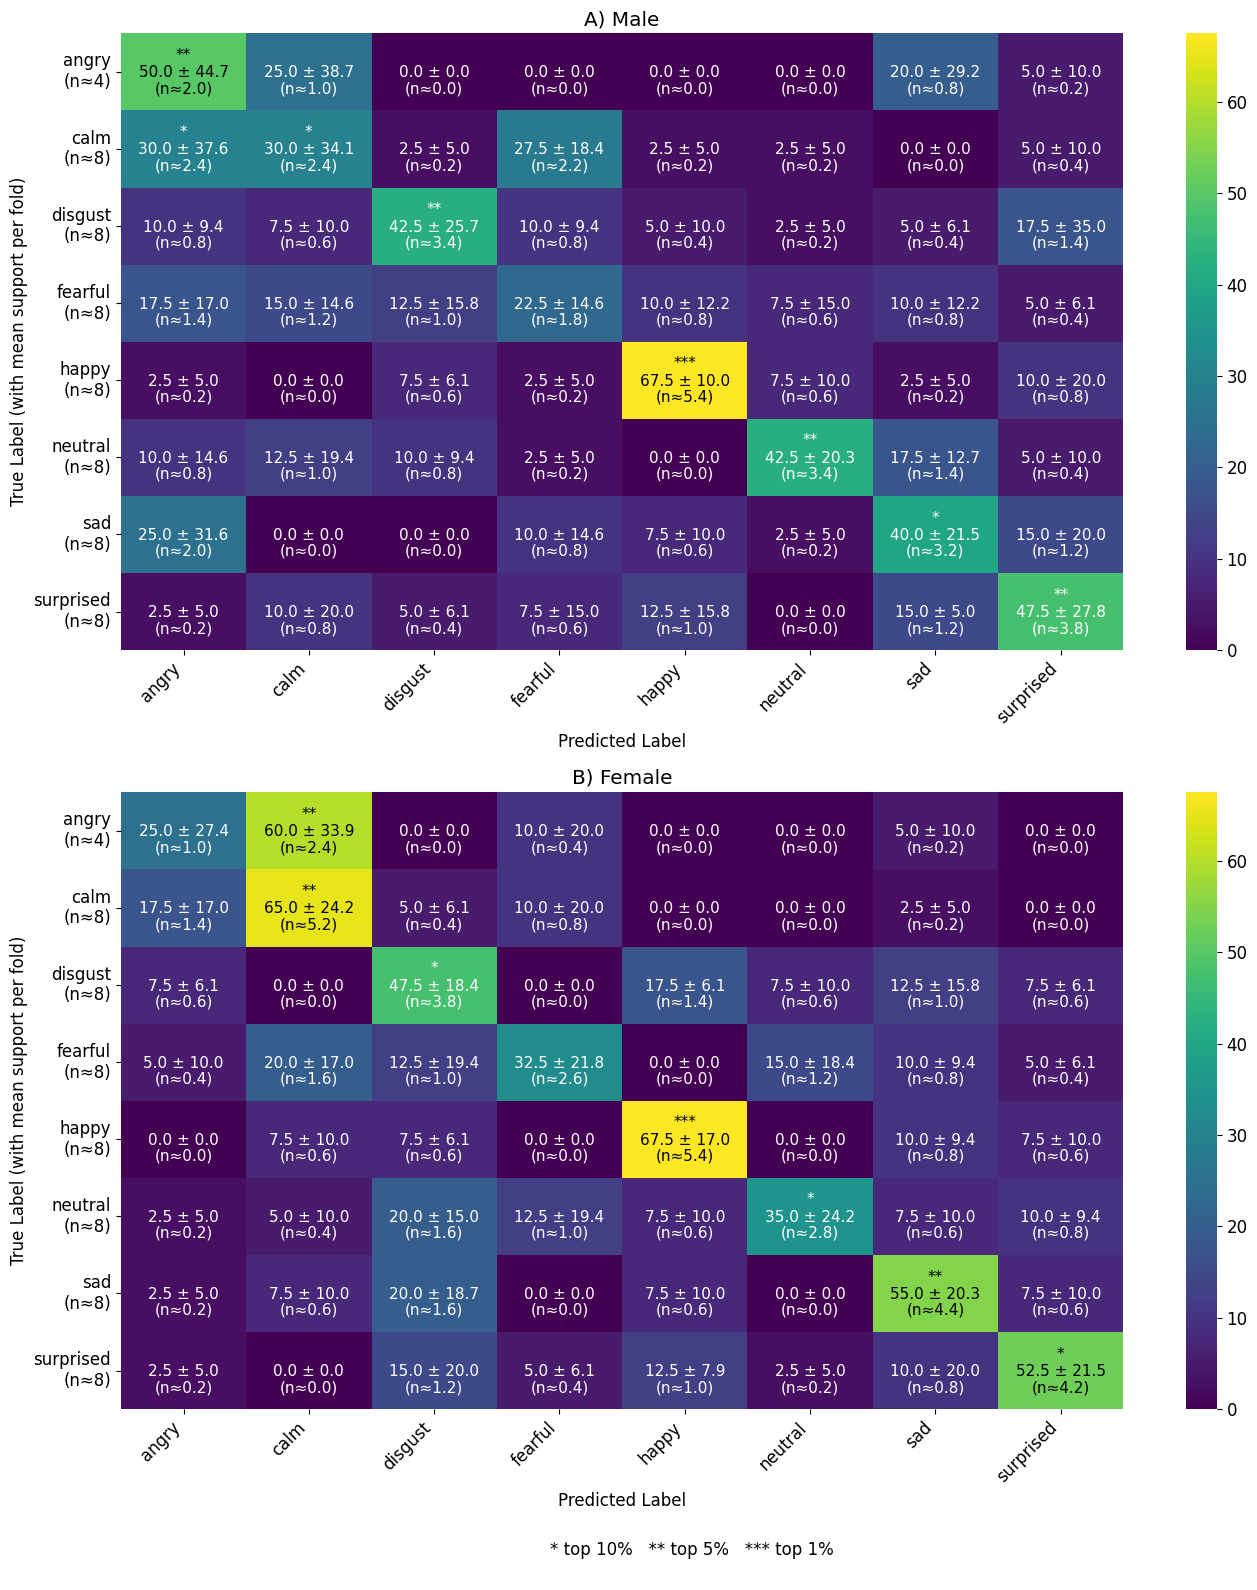

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'font.size': 12})
listik = ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']

fig, axes = plt.subplots(2, 1, figsize=(14, 16))

# Helper function for manual two-size annotations
def annotate_heatmap(ax, mean_cm, std_cm, mean_counts, thr_90, thr_95, thr_99):
    for i in range(mean_cm.shape[0]):
        for j in range(mean_cm.shape[1]):
            val = mean_cm[i, j]
            symbol = ""
            if val >= thr_99:
                symbol = "***"
            elif val >= thr_95:
                symbol = "**"
            elif val >= thr_90:
                symbol = "*"

            text_color = "white" if val < 50 else "black"

            main_text = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"
            ax.text(j + 0.5, i + 0.4, main_text,
                    ha='center', va='center',
                    fontsize=11, color=text_color)

            count_text = f"(n≈{mean_counts[i, j]:.1f})"
            ax.text(j + 0.5, i + 0.72, count_text,
                    ha='center', va='center',
                    fontsize=11, color=text_color)
            

# For female (conf_matrices is the raw count matrices)
mean_counts = np.mean(conf_matrices, axis=0)

# For male (conf_matrices_2 is the raw count matrices)
mean_counts_2 = np.mean(conf_matrices_male, axis=0)

# ---------------------------------------
# A) Male heatmap (TOP)
# ---------------------------------------
ax1 = axes[0]

flat_vals_2 = mean_cm_2.flatten()
thr_90_2 = np.percentile(flat_vals_2, 90)
thr_95_2 = np.percentile(flat_vals_2, 95)
thr_99_2 = np.percentile(flat_vals_2, 99)

mean_support_2 = np.mean(conf_matrices_male.sum(axis=2), axis=0)
row_labels_2 = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support_2)]

sns.heatmap(mean_cm_2, annot=False, cmap="viridis", cbar=True, ax=ax1)
annotate_heatmap(ax1, mean_cm_2, std_cm_2, mean_counts_2, thr_90_2, thr_95_2, thr_99_2)

ax1.set_xticks(np.arange(len(listik)) + 0.5)
ax1.set_yticks(np.arange(len(listik)) + 0.5)
ax1.set_xticklabels(listik, rotation=45, ha="right")
ax1.set_yticklabels(row_labels_2, rotation=0)
ax1.set_title("A) Male")
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label (with mean support per fold)")

# ---------------------------------------
# B) Female heatmap (BOTTOM)
# ---------------------------------------
ax2 = axes[1]

flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

mean_support = np.mean(conf_matrices.sum(axis=2), axis=0)
row_labels = [f"{name}\n(n≈{sup:.0f})" for name, sup in zip(listik, mean_support)]

sns.heatmap(mean_cm, annot=False, cmap="viridis", cbar=True, ax=ax2)
annotate_heatmap(ax2, mean_cm, std_cm, mean_counts, thr_90, thr_95, thr_99)

ax2.set_xticks(np.arange(len(listik)) + 0.5)
ax2.set_yticks(np.arange(len(listik)) + 0.5)
ax2.set_xticklabels(listik, rotation=45, ha="right")
ax2.set_yticklabels(row_labels, rotation=0)
ax2.set_title("B) Female")
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("True Label (with mean support per fold)")

# Shared caption
fig.text(0.5, 0.01,
         "* top 10%   ** top 5%   *** top 1%\n",
         ha="center", fontsize=12)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("cm_ravdess_speaker_ab.eps", bbox_inches='tight')
plt.show()